# 05 — MC1 failure-risk interpretation

Compare pattern-level failure risk to the MC1 annual baseline, inspect rare-pattern uncertainty, and report the available 2018 feature-level missingness-risk export.

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = Path("../exports")
assert EXPORT_DIR.exists(), f"Expected exports directory at {EXPORT_DIR.resolve()}"

def load_csv(name):
    path = EXPORT_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required export: {path}")
    return pd.read_csv(path)

def drop_export_index(df):
    return df.drop(columns=[c for c in df.columns if c.startswith("Unnamed:")], errors="ignore")

def attr_id(variable):
    return int(str(variable).split("_")[-1])

def canonical_pattern(serialized):
    return tuple(sorted(json.loads(serialized)))

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)


In [2]:
r18=load_csv("smart_2018_mc1_null_pattern_failure_risk.csv")
r19=load_csv("smart_2019_mc1_null_pattern_failure_risk.csv")
fc=load_csv("smart_2018_failure_coverage.csv")

## Dominant pattern versus annual MC1 baseline

In [3]:
rows=[]
for year,d in [(2018,r18),(2019,r19)]:
    x=d.sort_values("PATTERN_RANK").iloc[0]
    rows.append([year,x.NULL_PATTERN_ID,x.TOTAL_OBSERVATIONS,x.TARGET_1_COUNT,x.FAILURE_RATE_PERCENT,x.MC1_BASELINE_FAILURE_RATE_PERCENT,x.DIFFERENCE_FROM_BASELINE_PP,x.MC1_OBSERVATION_PERCENT])
result=pd.DataFrame(rows,columns=["YEAR","NULL_PATTERN_ID","ELIGIBLE_PATTERN_OBS","TARGET_1","PATTERN_FAILURE_RATE_PERCENT","MC1_BASELINE_PERCENT","DIFF_PP","MC1_OBSERVATION_PERCENT"])
display(result)

,YEAR,NULL_PATTERN_ID,ELIGIBLE_PATTERN_OBS,TARGET_1,PATTERN_FAILURE_RATE_PERCENT,MC1_BASELINE_PERCENT,DIFF_PP,MC1_OBSERVATION_PERCENT
0,2018,d237e8c2e2409dd8e304d0e30a9928d96ed499ac595f6e4c132ff2232474423e,48497097,51040,0.105243,0.105071,0.000172,99.736903
1,2019,d237e8c2e2409dd8e304d0e30a9928d96ed499ac595f6e4c132ff2232474423e,57328945,231678,0.404120,0.404121,-0.000001,99.973000


The dominant pattern tracks the annual MC1 baseline almost exactly. Therefore its absolute failure-rate increase from 2018 to 2019 is best interpreted as a population/base-rate change, not as the pattern becoming a stable warning signal.

## Rare patterns: rates and positive counts

In [4]:
for year,d in [(2018,r18),(2019,r19)]:
    rare=d[d.PATTERN_RANK.gt(1)].copy()
    rare["ABS_DIFF_PP"]=rare.DIFFERENCE_FROM_BASELINE_PP.abs()
    show=rare.sort_values("ABS_DIFF_PP",ascending=False).head(15)[["PATTERN_RANK","TOTAL_OBSERVATIONS","TARGET_1_COUNT","FAILURE_RATE_PERCENT","MC1_BASELINE_FAILURE_RATE_PERCENT","DIFFERENCE_FROM_BASELINE_PP","MC1_OBSERVATION_PERCENT"]]
    print(f"\n{year}: largest observed deviations among exported top patterns")
    display(show)


2018: largest observed deviations among exported top patterns


,PATTERN_RANK,TOTAL_OBSERVATIONS,TARGET_1_COUNT,FAILURE_RATE_PERCENT,MC1_BASELINE_FAILURE_RATE_PERCENT,DIFFERENCE_FROM_BASELINE_PP,MC1_OBSERVATION_PERCENT
35,36,177,2,1.129944,0.105071,1.024873,0.000364
32,33,179,1,0.558659,0.105071,0.453588,0.000368
31,32,182,1,0.549451,0.105071,0.444380,0.000374
22,23,192,1,0.520833,0.105071,0.415762,0.000395
21,22,198,1,0.505051,0.105071,0.399980,0.000407
19,20,199,1,0.502513,0.105071,0.397442,0.000409
12,13,207,1,0.483092,0.105071,0.378021,0.000426
7,8,246,1,0.406504,0.105071,0.301433,0.000506
18,19,200,0,0.000000,0.105071,-0.105071,0.000411
2,3,825,0,0.000000,0.105071,-0.105071,0.001697



2019: largest observed deviations among exported top patterns


,PATTERN_RANK,TOTAL_OBSERVATIONS,TARGET_1_COUNT,FAILURE_RATE_PERCENT,MC1_BASELINE_FAILURE_RATE_PERCENT,DIFFERENCE_FROM_BASELINE_PP,MC1_OBSERVATION_PERCENT
73,74,13,1,7.692308,0.404121,7.288187,0.000023
65,66,14,1,7.142857,0.404121,6.738736,0.000024
64,65,14,1,7.142857,0.404121,6.738736,0.000024
63,64,14,1,7.142857,0.404121,6.738736,0.000024
46,47,28,1,3.571429,0.404121,3.167308,0.000049
38,39,164,3,1.829268,0.404121,1.425147,0.000286
35,36,167,3,1.796407,0.404121,1.392286,0.000291
20,21,190,3,1.578947,0.404121,1.174826,0.000331
43,44,68,1,1.470588,0.404121,1.066467,0.000119
9,10,230,3,1.304348,0.404121,0.900227,0.000401


Large percentage differences in rare patterns must be read together with `TOTAL_OBSERVATIONS` and `TARGET_1_COUNT`; very small positive counts produce unstable rates.

## 2018 feature-level missingness versus failure

In [5]:
f18=load_csv("smart_2018_mc1_feature_missingness_risk.csv")
f18["ABS_DIFF_PP"]=f18.NULL_MINUS_PRESENT_PP.abs()
display(f18.sort_values("ABS_DIFF_PP",ascending=False).head(20))

f19_path=EXPORT_DIR / "smart_2019_mc1_feature_missingness_risk.csv"
if f19_path.exists():
    f19=pd.read_csv(f19_path)
    print("2019 feature-level file found; cross-year feature-level comparison can be added.")
    display(f19.head())
else:
    print("NOTE: smart_2019_mc1_feature_missingness_risk.csv was not supplied. No cross-year feature-level missingness-risk claim is made.")

,VARIABLE,NULL_OBSERVATIONS,PRESENT_OBSERVATIONS,FAILURE_RATE_WHEN_NULL_PERCENT,FAILURE_RATE_WHEN_PRESENT_PERCENT,NULL_MINUS_PRESENT_PP,ABS_DIFF_PP
0,N_5,120897,48504131,0.033913,0.105249,-0.071336,0.071336
1,R_5,120897,48504131,0.033913,0.105249,-0.071336,0.071336
2,R_1,120933,48504095,0.034730,0.105247,-0.070517,0.070517
3,N_1,120933,48504095,0.034730,0.105247,-0.070517,0.070517
4,R_9,120931,48504097,0.034731,0.105247,-0.070516,0.070516
5,N_9,120931,48504097,0.034731,0.105247,-0.070516,0.070516
6,R_174,120851,48504177,0.034754,0.105247,-0.070493,0.070493
7,N_174,120851,48504177,0.034754,0.105247,-0.070493,0.070493
8,R_12,120873,48504155,0.035575,0.105245,-0.069670,0.069670
9,N_12,120873,48504155,0.035575,0.105245,-0.069670,0.069670


NOTE: smart_2019_mc1_feature_missingness_risk.csv was not supplied. No cross-year feature-level missingness-risk claim is made.


## Failure-event coverage context

,FAILURE_YEAR,FAILURE_EVENTS,FAILED_DISKS,FIRST_FAILURE_DATE,LAST_FAILURE_DATE
0,2018,1964,1964,2018-01-03,2018-12-31
1,2019,8546,8546,2019-01-01,2019-12-31


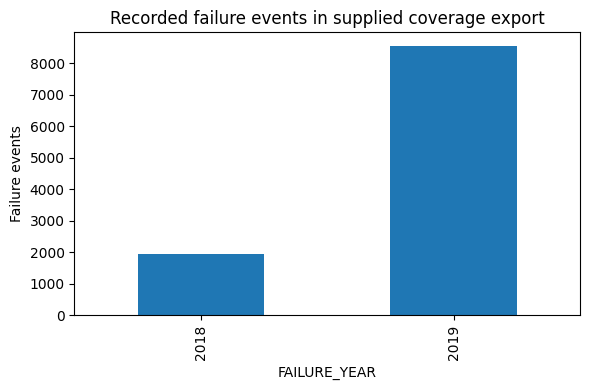

In [6]:
display(fc)
fc.plot(x="FAILURE_YEAR",y="FAILURE_EVENTS",kind="bar",legend=False,figsize=(6,4))
plt.ylabel("Failure events")
plt.title("Recorded failure events in supplied coverage export")
plt.tight_layout(); plt.show()

**Decision reproduced:** treat null-pattern EDA primarily as schema characterization. Preserve partial missing values for modeling, but focus future predictive work on actual SMART values and causal temporal features. Maintain temporal validation because target prevalence changes across years.